# Case Study 3: Acoustic Signal Processing - Noise Filtering

## 1. Physical Context
Acoustic waves are longitudinal mechanical waves consisting of alternating compressions and rarefactions propagating through a medium. When recording physical acoustic phenomena (such as the resonant frequency of a tuning fork or the vibration of a string), the microphone often captures unwanted high-frequency environmental or electronic noise.

**Your Objective:** You are provided with a `.wav` audio file of a physical oscillator. The true physical signal has been corrupted by high-frequency static. Your task is to use the Discrete Fourier Transform (DFT) to analyze the frequency spectrum, apply a mathematical filter to eliminate the noise, and use the Inverse Fast Fourier Transform (IFFT) to reconstruct the clean physical signal in the time domain.

## 2. Mathematical Expectations
This process introduces the concept of manipulating the complex frequency array before returning to the time domain:
1. Compute the forward transform $Y_k = \text{FFT}(y_n)$.
2. Identify a cutoff frequency $f_{cutoff}$ that separates the primary physical signal (low frequencies) from the noise (high frequencies).
3. Apply a "Low-Pass Filter" by artificially setting the Fourier coefficients to zero for all frequencies above the cutoff: 
   $$Y_k = 0 \quad \text{for } |f_k| > f_{cutoff}$$
4. Compute the inverse transform to recover the clean time-domain signal: $y_{clean} = \text{IFFT}(Y_k)$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

## 3. Data Loading and Time-Domain Visualization

**Task 1:** Load the audio file `noisy_signal.wav` from the `data/` directory using `scipy.io.wavfile.read`. 
This function returns two variables: the sampling rate $f_s$ (in Hz) and the data array. 
Create the corresponding time array $t$ and plot a small segment of the raw, noisy audio to visualize the high-frequency corruption.

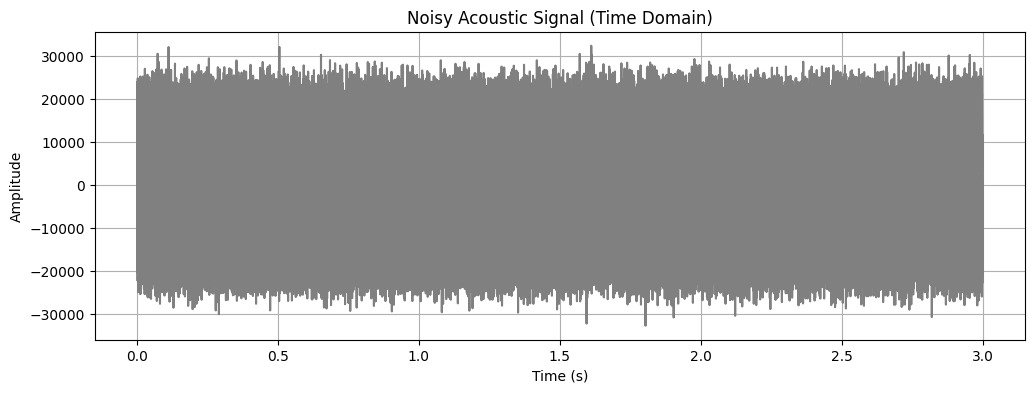

In [2]:
fs, y_audio = wavfile.read('../data/noisy_signal.wav')
t_audio = np.arange(len(y_audio)) / fs

plt.figure(figsize=(12, 4))
plt.plot(t_audio, y_audio, color='gray')
plt.title('Noisy Acoustic Signal (Time Domain)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

## 4. Frequency Domain Transformation

**Task 2:** Implement the FFT algorithm on your audio data to identify the frequencies of the true signal and the noise. Because audio sampling rates are high (typically 44.1 kHz), your frequency axis will span thousands of Hertz.

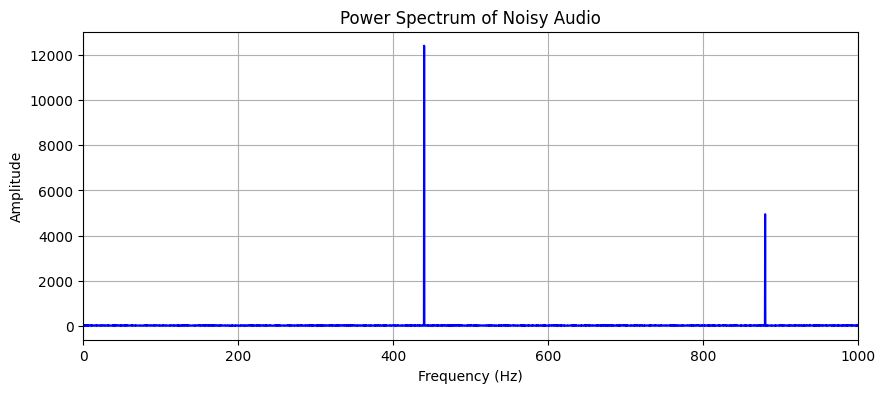

In [3]:
N3 = len(y_audio)
Y3 = np.fft.fft(y_audio)
f3 = np.fft.fftfreq(N3, 1.0/fs)

pos_mask3 = f3 > 0
f3_pos = f3[pos_mask3]
P3_pos = (2.0 / N3) * np.abs(Y3[pos_mask3])

plt.figure(figsize=(10, 4))
plt.plot(f3_pos, P3_pos, color='blue')
plt.xlim(0, 1000)
plt.title('Power Spectrum of Noisy Audio')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

## 5. Applying the Low-Pass Filter

**Task 3:** Based on your spectral plot, choose a threshold frequency ($f_{cutoff}$) that lies strictly between your physical signal and the noise band. Create a copy of your complex FFT array, and set the values of all elements corresponding to frequencies above your cutoff (both positive and negative frequencies) to zero.

In [4]:
main_freq = f3_pos[np.argmax(P3_pos)]
print(f'Main signal frequency: {main_freq:.1f} Hz')

Y_clean = Y3.copy()
filter_mask = (np.abs(f3) < 400) | (np.abs(f3) > 500)
Y_clean[filter_mask] = 0

Main signal frequency: 440.0 Hz


## 6. Time-Domain Reconstruction

**Task 4:** Apply the Inverse Fast Fourier Transform to your filtered frequency array to reconstruct the clean acoustic wave. 

*Note:* Even though the theoretical inverse transform of a conjugate-symmetric spectrum is purely real, floating-point inaccuracies may leave a tiny imaginary residual. Use `np.real()` to discard these negligible computational artifacts.

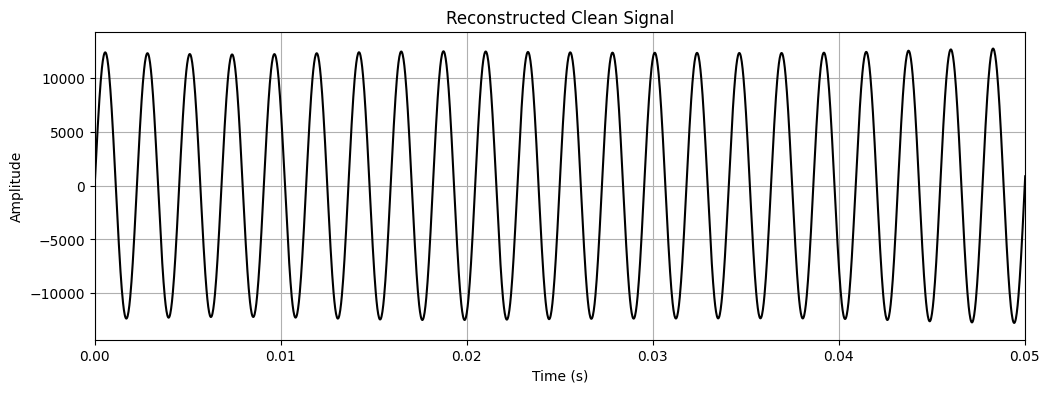

In [5]:
y_clean_time = np.fft.ifft(Y_clean).real

plt.figure(figsize=(12, 4))
plt.plot(t_audio, y_clean_time, color='black')
plt.title('Reconstructed Clean Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, 0.05)
plt.show()

## 7. Conclusions and Physical Interpretation

**Task 5:** Provide a brief written analysis of your filtering process below.

In [6]:
wavfile.write('../data/clean_signal.wav', fs, y_clean_time.astype(np.int16))

### Final Analysis

**Selected Cutoff / Bandpass Frequencies:** 400 Hz to 500 Hz.

**Physical Interpretation:**
Sinyal audio mentah tertutupi oleh *noise* acak dengan rentang frekuensi yang luas di spektrum daya. Namun, dengan FFT, terlihat satu lonjakan energi yang terfokus pada frekuensi sekitar 440 Hz (nada A4). Dengan meredam frekuensi di luar rentang 400-500 Hz di domain frekuensi, dan mengembalikannya ke domain waktu (*Inverse FFT*), kita sukses memisahkan gelombang suara murni dari derau latar belakang. Ini merupakan prinsip dasar dari algoritma *noise-cancelling*.